# Location-Specific Renewable Generation Change Profile

This notebook provides tools for analyzing how renewable energy generation at a specific location will change under future climate conditions. You can analyze any location by providing either:
- **Latitude/Longitude coordinates** - finds the nearest valid grid cell
- **Shapefile** - averages across all grid cells within the region

## Analysis Products

For your specified location and renewable resource type, this notebook generates:

1. **Annual profile comparison** - Shows average capacity factor by day of year for historical (GWL 0.8°C) and future warming levels
2. **Standard Energy Index (SEI) heatmaps** - Identifies low-generation periods across time for each climate model
3. **Seasonal change summary** - Quantifies how the number of low-generation days changes by season

## Renewable Resource Types

- `pv` with `utility` module (solar)
- `windpower` with `onshore` module (land-based wind)
- `windpower` with `offshore` module (ocean wind - only works for coastal/ocean locations)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Point

# Import local modules
import sys
sys.path.append('../../src')
from renewable_data_load import (
    get_ren_data_concat, 
    get_gwl_crossing_period,
    sim_name_dict,
    ren_sims
)
from sei_computation import compute_sei, stack_doy_year_to_time
from plotting_config import model_colors, gwl_colors, model_order

# Apply consistent plotting style
plt.style.use('../../renewable_analysis.mplstyle')

## Configuration

Specify your location and analysis parameters below.

In [2]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Location specification (choose ONE method):
# Method 1: Provide lat/lon coordinates
USE_LATLON = True
target_lat = 33.9  
target_lon = -116.6

# Method 2: Provide path to shapefile (set USE_LATLON = False to use this)
#shapefile_path = "../../data/load_zone_shapefiles/your_region.shp"

# Resource specification
resource = "windpower"  # Options: "pv", "windpower"
module = "onshore"  # Options: "utility" (for pv), "onshore" or "offshore" (for windpower)
domain = "d02"  # Options: "d02" (9km), "d03" (3km - offshore wind only)

# Analysis parameters
reference_gwl = 0.8  # Historical reference warming level
future_gwl = 3.0  # Future warming level to compare against
variable = "cf"  # capacity factor
frequency = "day"  # daily data

# Threshold for defining low-generation days (10th percentile standard)
low_gen_percentile = 0.1

# Climate models to analyze (these four have the most complete data)
simulations = ["ec-earth3", "mpi-esm1-2-hr", "miroc6", "taiesm1"]

# Data directory for threshold files
data_directory = "../../data/"

# Season definitions (for seasonal summaries)
seasons_map = {1: 'JFM', 4: 'AMJ', 7: 'JAS', 10: 'OND'}
season_order = ['JFM', 'AMJ', 'JAS', 'OND']

## Helper Functions

These functions extract and process data for your specified location.

In [3]:
def find_nearest_valid_point(ds, target_lat, target_lon):
    """
    Find the nearest non-NaN grid cell to the target coordinates.
    
    Parameters
    ----------
    ds : xr.DataArray
        Data array with spatial coordinates (must have lat/lon)
    target_lat : float
        Target latitude
    target_lon : float
        Target longitude
        
    Returns
    -------
    tuple
        (x_idx, y_idx) of the nearest valid grid cell
    """
    # Select first time point to check for valid data
    sample_data = ds.isel(time=0)
    
    # Calculate distance from target point
    lat_dist = np.abs(ds.lat - target_lat)
    lon_dist = np.abs(ds.lon - target_lon)
    
    # Combined distance (simple Euclidean in lat/lon space)
    distance = np.sqrt(lat_dist**2 + lon_dist**2)
    
    # Mask out NaN locations
    distance_masked = distance.where(~np.isnan(sample_data))
    
    # Find minimum distance
    min_idx = distance_masked.argmin(...)
    y_idx = int(min_idx['y'].values)
    x_idx = int(min_idx['x'].values)
    
    actual_lat = float(ds.lat.isel(y=y_idx, x=x_idx).values)
    actual_lon = float(ds.lon.isel(y=y_idx, x=x_idx).values)
    
    print(f"Target location: ({target_lat:.2f}°N, {target_lon:.2f}°E)")
    print(f"Nearest valid grid cell: ({actual_lat:.2f}°N, {actual_lon:.2f}°E)")
    print(f"Grid indices: x={x_idx}, y={y_idx}")
    
    return x_idx, y_idx


def extract_location_data(ds, use_latlon=True, lat=None, lon=None, shapefile_path=None):
    """
    Extract data for a specific location (point or region).
    
    Parameters
    ----------
    ds : xr.DataArray
        Full spatial dataset
    use_latlon : bool
        If True, use lat/lon point. If False, use shapefile
    lat, lon : float, optional
        Target coordinates (required if use_latlon=True)
    shapefile_path : str, optional
        Path to shapefile (required if use_latlon=False)
        
    Returns
    -------
    xr.DataArray
        Extracted timeseries for the location (spatial dims removed or averaged)
    """
    if use_latlon:
        if lat is None or lon is None:
            raise ValueError("lat and lon must be provided when use_latlon=True")
        
        x_idx, y_idx = find_nearest_valid_point(ds, lat, lon)
        location_data = ds.isel(x=x_idx, y=y_idx)
        
    else:
        if shapefile_path is None:
            raise ValueError("shapefile_path must be provided when use_latlon=False")
        
        # Read shapefile
        gdf = gpd.read_file(shapefile_path)
        
        # Convert to same CRS as data (assuming WGS84 for lat/lon)
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
        
        # Clip data to shapefile region
        # Create mask for points within shapefile
        lons = ds.lon.values
        lats = ds.lat.values
        
        # Flatten and create points
        points = [Point(lon, lat) for lon, lat in zip(lons.flatten(), lats.flatten())]
        points_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
        
        # Find points within shapefile
        within_mask = points_gdf.within(gdf.unary_union)
        within_mask = within_mask.values.reshape(lons.shape)
        
        # Apply mask and take spatial mean
        ds_masked = ds.where(within_mask)
        location_data = ds_masked.mean(dim=['x', 'y'], skipna=True)
        
        n_cells = int(within_mask.sum())
        print(f"Averaging over {n_cells} grid cells within shapefile region")
    
    return location_data

In [4]:
def plot_annual_profile_comparison(
    location_data_dict, 
    reference_gwl=0.8, 
    future_gwl=2.0,
    resource_name="Renewable Generation",
    figsize=(12, 5),
    smoothing_window=14
):
    """
    Plot multi-model mean annual profile comparing two warming levels.
    
    Parameters
    ----------
    location_data_dict : dict
        Dictionary with simulation names as keys and location timeseries as values
        Each value should be an xarray DataArray with time dimension
    reference_gwl : float
        Reference warming level (typically 0.8°C)
    future_gwl : float
        Future warming level to compare (typically 2.0°C)
    resource_name : str
        Name of resource for plot title
    figsize : tuple
        Figure size (width, height)
    smoothing_window : int or None
        Number of days for rolling mean smoothing. Default is 14 days.
        Set to None or 0 to disable smoothing.
        
    Returns
    -------
    fig, ax
        Matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Storage for multi-model means
    ref_profiles = []
    fut_profiles = []
    
    for sim in model_order:
        if sim not in location_data_dict:
            continue
            
        ds = location_data_dict[sim]
        
        # Get GWL periods
        WRF_sim_name = sim_name_dict[sim]
        model = WRF_sim_name.split("_")[1]
        ensemble_member = WRF_sim_name.split("_")[2]
        
        ref_start, ref_end = get_gwl_crossing_period(model, ensemble_member, reference_gwl)
        fut_start, fut_end = get_gwl_crossing_period(model, ensemble_member, future_gwl)
        
        # Extract periods
        ds_ref = ds.sel(time=slice(f"{ref_start}", f"{ref_end}"))
        ds_fut = ds.sel(time=slice(f"{fut_start}", f"{fut_end}"))
        
        # Apply smoothing to timeseries if requested (before groupby)
        if smoothing_window and smoothing_window > 0:
            ds_ref = ds_ref.rolling(time=smoothing_window, center=True).mean()
            ds_fut = ds_fut.rolling(time=smoothing_window, center=True).mean()
        
        # Calculate day-of-year means
        ref_profile = ds_ref.groupby('time.dayofyear').mean()
        fut_profile = ds_fut.groupby('time.dayofyear').mean()
        
        ref_profiles.append(ref_profile)
        fut_profiles.append(fut_profile)
    
    # Calculate multi-model means
    ref_mean = xr.concat(ref_profiles, dim='model').mean(dim='model')
    fut_mean = xr.concat(fut_profiles, dim='model').mean(dim='model')
    
    # Calculate spread (min-max) for shading
    ref_min = xr.concat(ref_profiles, dim='model').min(dim='model')
    ref_max = xr.concat(ref_profiles, dim='model').max(dim='model')
    fut_min = xr.concat(fut_profiles, dim='model').min(dim='model')
    fut_max = xr.concat(fut_profiles, dim='model').max(dim='model')
    
    # Extract location info for title (if single point)
    first_sim = list(location_data_dict.values())[0]
    location_text = ""
    if 'lat' in first_sim.coords and 'lon' in first_sim.coords:
        # Check if lat/lon are scalars (point location) vs arrays (regional average)
        if first_sim.lat.ndim == 0 and first_sim.lon.ndim == 0:
            actual_lat = float(first_sim.lat.values)
            actual_lon = float(first_sim.lon.values)
            location_text = f" at ({actual_lat:.2f}°N, {actual_lon:.2f}°E)"
    
    # Plot
    doys = ref_mean.dayofyear
    
    # Reference period
    ax.plot(doys, ref_mean, color=gwl_colors[reference_gwl], 
            linewidth=2.5, label=f'GWL {reference_gwl}°C', zorder=3)
    ax.fill_between(doys, ref_min, ref_max,
                    color=gwl_colors[reference_gwl], alpha=0.3, zorder=2)
    
    # Future period
    ax.plot(doys, fut_mean, color=gwl_colors[future_gwl],
            linewidth=2.5, label=f'GWL {future_gwl}°C', zorder=3)
    ax.fill_between(doys, fut_min, fut_max,
                    color=gwl_colors[future_gwl], alpha=0.3, zorder=2)
    
    # Formatting
    smooth_text = f' ({smoothing_window}-day smoothing)' if smoothing_window and smoothing_window > 0 else ''
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Capacity Factor')
    ax.set_title(f'Annual Profile: {resource_name}{smooth_text}{location_text}\nMulti-Model Mean (shaded: min-max range)',
                fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 365)
    
    plt.tight_layout()
    
    return fig, ax

## 1. Annual Profile Analysis

Compare the seasonal cycle of renewable generation between historical and future warming levels.

In [5]:
location_data_dict = {}

for sim in simulations:
    print(f"Loading {sim}...")
    
    # Load full dataset
    ds = get_ren_data_concat(resource, module, domain, variable, frequency, sim)
    
    # Extract location data
    location_ts = extract_location_data(
        ds, 
        use_latlon=USE_LATLON,
        lat=target_lat if USE_LATLON else None,
        lon=target_lon if USE_LATLON else None,
        shapefile_path=shapefile_path if not USE_LATLON else None
    )
    
    location_data_dict[sim] = location_ts
    print()

print("Data loading complete!")

Loading ec-earth3...
Target location: (33.90°N, -116.60°E)
Nearest valid grid cell: (33.98°N, -116.52°E)
Grid indices: x=72, y=111

Loading mpi-esm1-2-hr...
Target location: (33.90°N, -116.60°E)
Nearest valid grid cell: (33.98°N, -116.52°E)
Grid indices: x=72, y=111

Loading miroc6...
Target location: (33.90°N, -116.60°E)
Nearest valid grid cell: (33.98°N, -116.52°E)
Grid indices: x=72, y=111

Loading taiesm1...
Target location: (33.90°N, -116.60°E)
Nearest valid grid cell: (33.98°N, -116.52°E)
Grid indices: x=72, y=111

Data loading complete!


In [6]:
for sim in simulations:
    location_data_dict[sim] = location_data_dict[sim].compute()

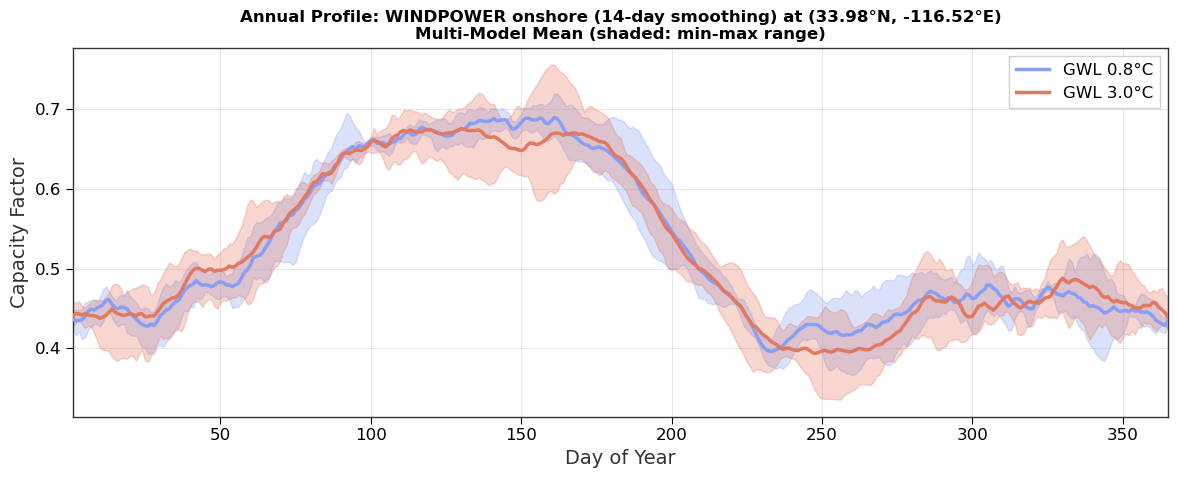

In [7]:
# Generate annual profile comparison
# Adjust smoothing_window to control smoothing:
#   - 14 (default): 2-week rolling average
#   - 7: 1-week rolling average  
#   - 30: 1-month rolling average
#   - None or 0: No smoothing (raw daily values)
#
# Note: Smoothing is applied to the full timeseries before grouping by day of year,
# so year boundaries (Dec 31 → Jan 1) are handled naturally without edge effects.

fig, ax = plot_annual_profile_comparison(
    location_data_dict,
    reference_gwl=reference_gwl,
    future_gwl=future_gwl,
    resource_name=f"{resource.upper()} {module}",
    smoothing_window=14  # Adjust this value to change smoothing
)

plt.show()

## 2. Standard Energy Index (SEI) Analysis

Compute and visualize SEI to identify periods of anomalously low generation. SEI is a standardized index where:
- **Negative values** (blue) = Below-normal generation
- **Positive values** (red) = Above-normal generation
- **Values < -1.28** = Low generation periods (below 10th percentile)

In [8]:
def compute_location_sei(location_ts, simulation, reference_gwl=0.8, window_size=60):
    """
    Compute SEI for a location timeseries.
    
    Parameters
    ----------
    location_ts : xr.DataArray
        Timeseries at a single location
    simulation : str
        Simulation name (e.g., 'ec-earth3')
    reference_gwl : float
        Reference warming level for defining normal conditions
    window_size : int
        Rolling window size for SEI calculation (days)
        
    Returns
    -------
    xr.DataArray
        SEI with dimensions (dayofyear, year)
    """
    # Get reference period
    WRF_sim_name = sim_name_dict[simulation]
    model = WRF_sim_name.split("_")[1]
    ensemble_member = WRF_sim_name.split("_")[2]
    
    ref_start, ref_end = get_gwl_crossing_period(model, ensemble_member, reference_gwl)
    
    # Extract reference period
    ref_data = location_ts.sel(time=slice(f"{ref_start}", f"{ref_end}"))
    
    # Compute SEI
    sei = compute_sei(ref_data, location_ts, window_size=window_size, fill_missing_year=True)
    
    return sei


def plot_sei_heatmap(sei_data, simulation, vmin=-3, vmax=3, figsize=(14, 6)):
    """
    Plot SEI as a heatmap (year vs dayofyear).
    
    Parameters
    ----------
    sei_data : xr.DataArray
        SEI with dimensions (dayofyear, year)
    simulation : str
        Simulation name for title
    vmin, vmax : float
        Color scale limits
    figsize : tuple
        Figure size
        
    Returns
    -------
    fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.pcolormesh(
        sei_data.dayofyear, 
        sei_data.year, 
        sei_data.T,  # Transpose so year is on y-axis
        cmap='PuOr',
        vmin=vmin,
        vmax=vmax,
        shading='nearest'
    )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Standard Energy Index')
    

    
    # Formatting
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Year')
    ax.set_title(f'Standard Energy Index: {simulation.upper()}',
                fontsize=12, fontweight='bold')
    ax.set_xlim(1, 365)
    
    plt.tight_layout()
    
    return fig, ax

### Compute SEI for Each Model

In [9]:
# Compute SEI for all simulations
print("Computing SEI for each climate model...")
print("="*60)

sei_dict = {}

for sim in simulations:
    print(f"Computing SEI for {sim}...")
    
    sei = compute_location_sei(
        location_data_dict[sim],
        sim,
        reference_gwl=reference_gwl,
        window_size=30
    )
    
    sei_dict[sim] = sei
    print(f"  SEI shape: {sei.shape}")
    print()

print("SEI computation complete!")

Computing SEI for each climate model...
Computing SEI for ec-earth3...
  SEI shape: (365, 118)

Computing SEI for mpi-esm1-2-hr...
  SEI shape: (365, 118)

Computing SEI for miroc6...
  SEI shape: (365, 118)

Computing SEI for taiesm1...
  SEI shape: (365, 118)

SEI computation complete!


### Plot SEI Heatmaps (Individual Models)

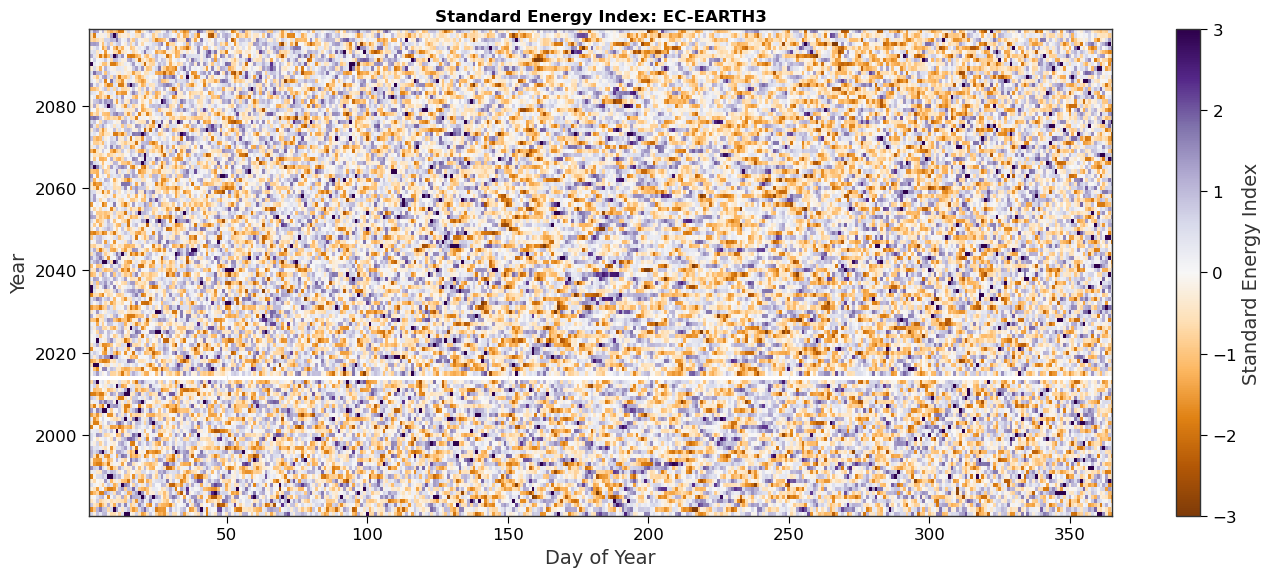

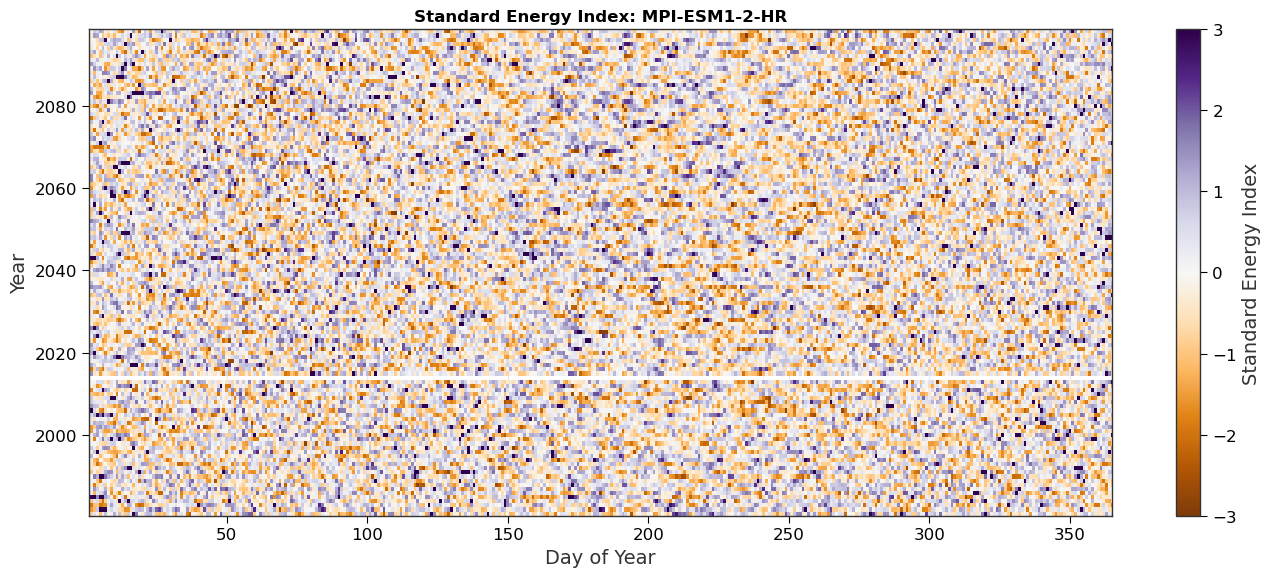

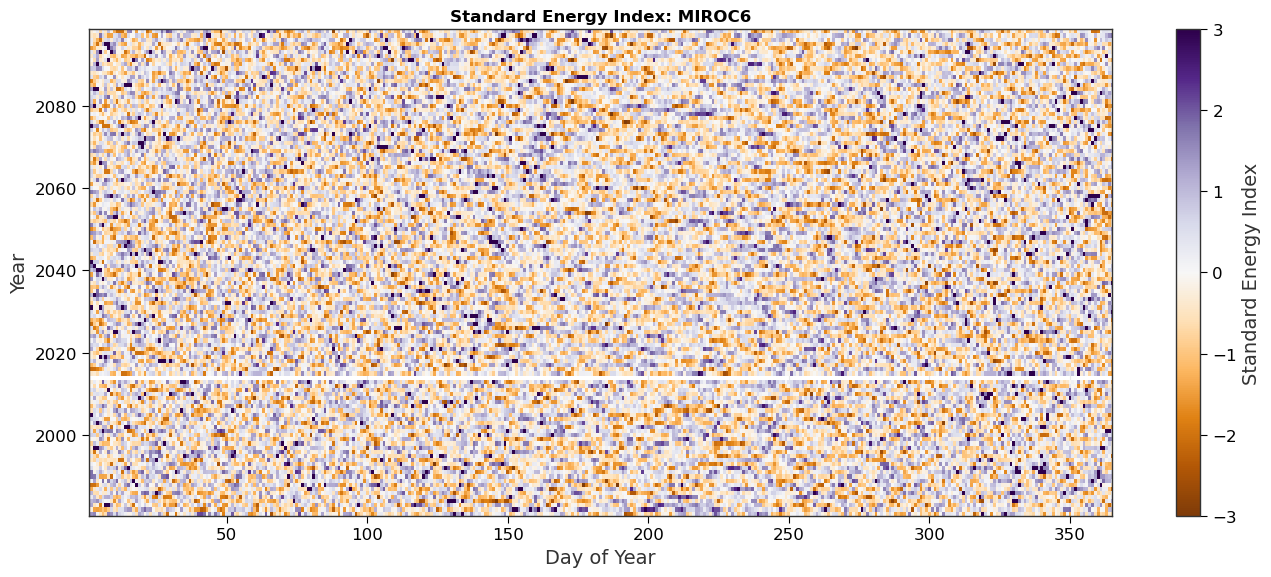

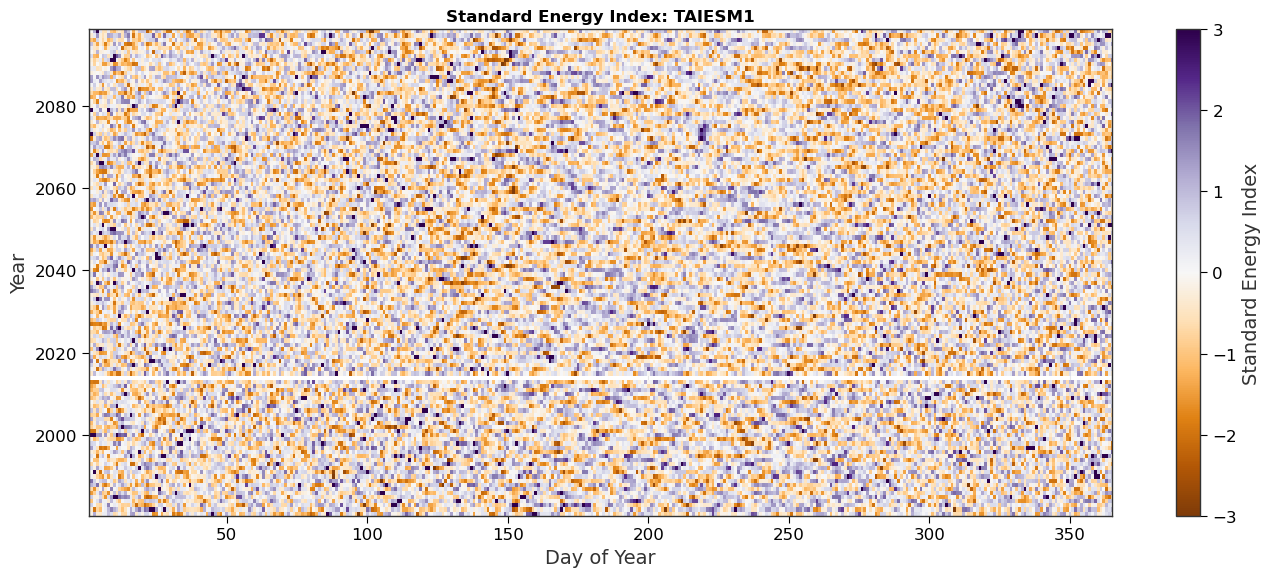

In [10]:
# Plot SEI for each model
for sim in simulations:
    fig, ax = plot_sei_heatmap(sei_dict[sim], sim)
    plt.show()

### Optional: Multi-Model Mean SEI

Calculating multi-model mean SEI...


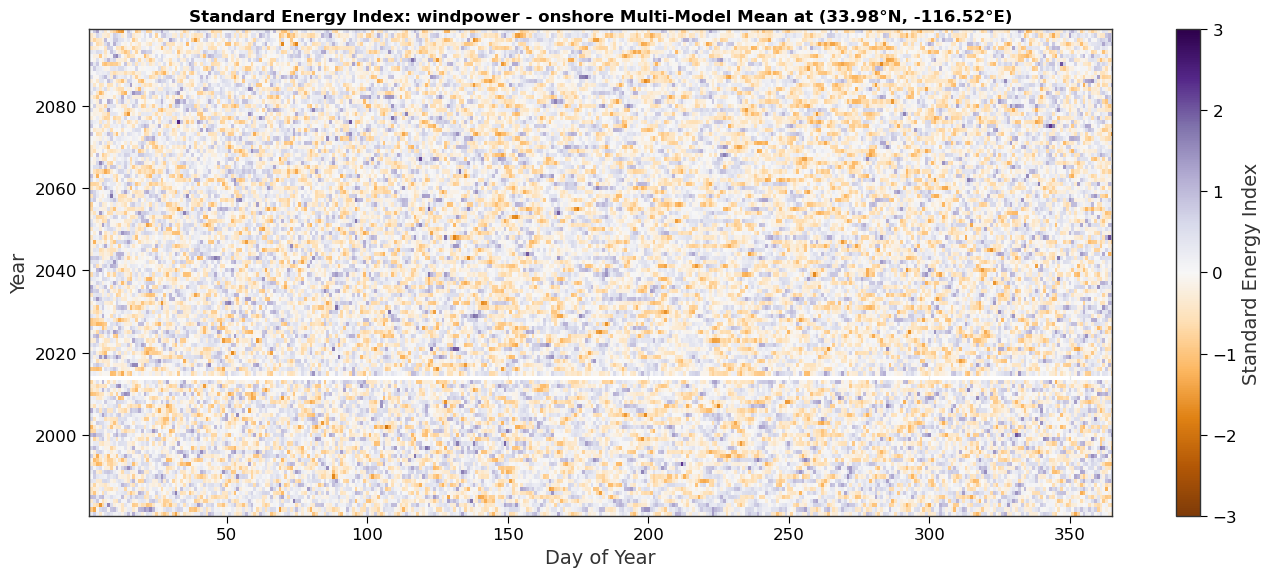

In [11]:
# Calculate and plot multi-model mean SEI
print("Calculating multi-model mean SEI...")

# Concatenate all models
sei_concat = xr.concat([sei_dict[sim] for sim in simulations], 
                       dim='model')

# Calculate mean
sei_mmm = sei_concat.mean(dim='model')

# Plot
fig, ax = plot_sei_heatmap(sei_mmm, "Multi-Model Mean", vmin=-3, vmax=3)

location_text = ""
first_sim = list(location_data_dict.values())[0]
if 'lat' in first_sim.coords and 'lon' in first_sim.coords:
    if first_sim.lat.ndim == 0 and first_sim.lon.ndim == 0:
        actual_lat = float(first_sim.lat.values)
        actual_lon = float(first_sim.lon.values)
        location_text = f" at ({actual_lat:.2f}°N, {actual_lon:.2f}°E)"

plt.title(f'Standard Energy Index: {resource} - {module} Multi-Model Mean{location_text}',
          fontsize=12, fontweight='bold')

plt.show()

## 3. Low-Generation Day Analysis

Create masks identifying low-generation days and analyze how their frequency changes by season.

In [12]:
def create_low_generation_mask(sei_data, threshold=-1.28):
    """
    Create binary mask for low-generation days based on SEI threshold.
    
    Parameters
    ----------
    sei_data : xr.DataArray
        SEI values (dayofyear, year)
    threshold : float
        SEI threshold below which generation is considered low
        Default is -1.28 (approximately 10th percentile)
        
    Returns
    -------
    xr.DataArray
        Binary mask (1 = low generation, 0 = normal/high generation)
    """
    mask = (sei_data < threshold).astype(int)
    mask.name = 'low_gen_mask'
    mask.attrs['threshold'] = threshold
    mask.attrs['description'] = f'Binary mask: 1 = low generation (SEI < {threshold}), 0 = normal/high'
    
    return mask


def compute_seasonal_change(mask_dict, reference_gwl=0.8, future_gwl=2.0):
    """
    Compute change in low-generation days by season for each model.
    
    Parameters
    ----------
    mask_dict : dict
        Dictionary with simulation names as keys and masks with (dayofyear, year) dims
    reference_gwl : float
        Reference warming level
    future_gwl : float
        Future warming level
        
    Returns
    -------
    pd.DataFrame
        Change in low-generation days by season for each model
    """
    results = []
    
    for sim in mask_dict.keys():
        # Convert mask back to timeseries format
        mask = mask_dict[sim]
        mask_ts = stack_doy_year_to_time(mask, calendar='noleap')
        
        # Get GWL periods
        WRF_sim_name = sim_name_dict[sim]
        model = WRF_sim_name.split("_")[1]
        ensemble_member = WRF_sim_name.split("_")[2]
        
        ref_start, ref_end = get_gwl_crossing_period(model, ensemble_member, reference_gwl)
        fut_start, fut_end = get_gwl_crossing_period(model, ensemble_member, future_gwl)
        
        # Extract periods
        mask_ref = mask_ts.sel(time=slice(f"{ref_start}", f"{ref_end}"))
        mask_fut = mask_ts.sel(time=slice(f"{fut_start}", f"{fut_end}"))
        
        # Resample to quarters starting in January
        ref_quarterly = mask_ref.resample(time='QS-JAN').sum()
        fut_quarterly = mask_fut.resample(time='QS-JAN').sum()
        
        # Map months to season labels
        ref_months = ref_quarterly.time.dt.month.values
        fut_months = fut_quarterly.time.dt.month.values
        
        ref_season_labels = xr.DataArray(
            [seasons_map[m] for m in ref_months],
            dims=['time'],
            coords={'time': ref_quarterly.time}
        )
        fut_season_labels = xr.DataArray(
            [seasons_map[m] for m in fut_months],
            dims=['time'],
            coords={'time': fut_quarterly.time}
        )
        
        # Group by season and calculate means
        ref_seasonal = ref_quarterly.groupby(ref_season_labels).mean().rename({'group': 'season'})
        fut_seasonal = fut_quarterly.groupby(fut_season_labels).mean().rename({'group': 'season'})
        
        # Ensure consistent season ordering
        ref_seasonal = ref_seasonal.reindex(season=season_order)
        fut_seasonal = fut_seasonal.reindex(season=season_order)
        
        # Calculate change
        delta = fut_seasonal - ref_seasonal
        
        # Store results
        for season in season_order:
            results.append({
                'simulation': sim,
                'season': season,
                'reference_days': float(ref_seasonal.sel(season=season).values),
                'future_days': float(fut_seasonal.sel(season=season).values),
                'change': float(delta.sel(season=season).values)
            })
    
    return pd.DataFrame(results)


def plot_seasonal_changes(seasonal_df, figsize=(8, 6), resource_name=None, location_data_dict=None):
    """
    Plot seasonal changes in low-generation days for each model.
    
    Parameters
    ----------
    seasonal_df : pd.DataFrame
        DataFrame from compute_seasonal_change
    figsize : tuple
        Figure size
    resource_name : str, optional
        Name of resource for title
    location_data_dict : dict, optional
        Dictionary of location data for extracting coordinates
        
    Returns
    -------
    fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define unique marker shapes for each model
    markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond
    
    # Set up season positions
    seasons = season_order
    x = np.arange(len(seasons))
    
    # Plot scatter points for each model
    for i, sim in enumerate(simulations):
        sim_data = seasonal_df[seasonal_df['simulation'] == sim]
        changes = [sim_data[sim_data['season'] == s]['change'].values[0] for s in seasons]
        
        ax.scatter(x, changes, 
                  marker=markers[i],
                  s=120,  # marker size
                  color=model_colors.get(sim, 'gray'),
                  label=sim.upper(),
                  edgecolors='black',
                  linewidths=0.5,
                  alpha=0.8,
                  zorder=3)
    
    # Extract location info for title (if provided)
    location_text = ""
    if location_data_dict is not None:
        first_sim = list(location_data_dict.values())[0]
        if 'lat' in first_sim.coords and 'lon' in first_sim.coords:
            # Check if lat/lon are scalars (point location) vs arrays (regional average)
            if first_sim.lat.ndim == 0 and first_sim.lon.ndim == 0:
                actual_lat = float(first_sim.lat.values)
                actual_lon = float(first_sim.lon.values)
                location_text = f" at ({actual_lat:.2f}°N, {actual_lon:.2f}°E)"
    
    # Build title
    resource_text = f"{resource_name}: " if resource_name else ""
    
    # Formatting
    ax.set_xlabel('Season')
    ax.set_ylabel('Change in Low-Generation Days \n(days per season)')
    ax.set_title(f'{resource_text}Seasonal Change in Low-Generation Days{location_text}\n({future_gwl}°C - {reference_gwl}°C)',
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(seasons)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.legend(loc='best', ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    return fig, ax

### Create Low-Generation Masks

In [13]:
# Create masks for all simulations
print("Creating low-generation masks...")
print("="*60)

mask_dict = {}

for sim in simulations:
    print(f"Creating mask for {sim}...")
    mask = create_low_generation_mask(sei_dict[sim], threshold=-1.28)
    mask_dict[sim] = mask
    
    # Calculate total low-generation days across entire period
    total_low_days = float(mask.sum().values)
    total_days = mask.size
    pct_low = (total_low_days / total_days) * 100
    
    print(f"  Total low-generation days: {total_low_days:.0f} / {total_days} ({pct_low:.1f}%)")

print("\\nMask creation complete!")

Creating low-generation masks...
Creating mask for ec-earth3...
  Total low-generation days: 4304 / 43070 (10.0%)
Creating mask for mpi-esm1-2-hr...
  Total low-generation days: 4136 / 43070 (9.6%)
Creating mask for miroc6...
  Total low-generation days: 4200 / 43070 (9.8%)
Creating mask for taiesm1...
  Total low-generation days: 4380 / 43070 (10.2%)
\nMask creation complete!


### Calculate and Plot Seasonal Changes

In [14]:
# Compute seasonal changes
print(f"Computing seasonal changes between GWL {reference_gwl}°C and {future_gwl}°C...")

seasonal_changes = compute_seasonal_change(
    mask_dict,
    reference_gwl=reference_gwl,
    future_gwl=future_gwl
)

# Display table
print("\\nSeasonal Change Summary:")
print("="*60)
print(seasonal_changes.to_string(index=False))

Computing seasonal changes between GWL 0.8°C and 3.0°C...
\nSeasonal Change Summary:
   simulation season  reference_days  future_days    change
    ec-earth3    JFM        8.500000     7.666667 -0.833333
    ec-earth3    AMJ        8.400000     8.766667  0.366667
    ec-earth3    JAS        8.900000     9.233333  0.333333
    ec-earth3    OND        8.933333     8.966667  0.033333
mpi-esm1-2-hr    JFM        8.900000     9.133333  0.233333
mpi-esm1-2-hr    AMJ        8.733333     7.533333 -1.200000
mpi-esm1-2-hr    JAS        9.600000     8.166667 -1.433333
mpi-esm1-2-hr    OND        9.200000     8.266667 -0.933333
       miroc6    JFM        8.633333     7.133333 -1.500000
       miroc6    AMJ        8.500000     8.800000  0.300000
       miroc6    JAS        8.733333     9.200000  0.466667
       miroc6    OND        8.733333     9.133333  0.400000
      taiesm1    JFM        8.266667     8.666667  0.400000
      taiesm1    AMJ        8.533333    10.266667  1.733333
      taiesm1  

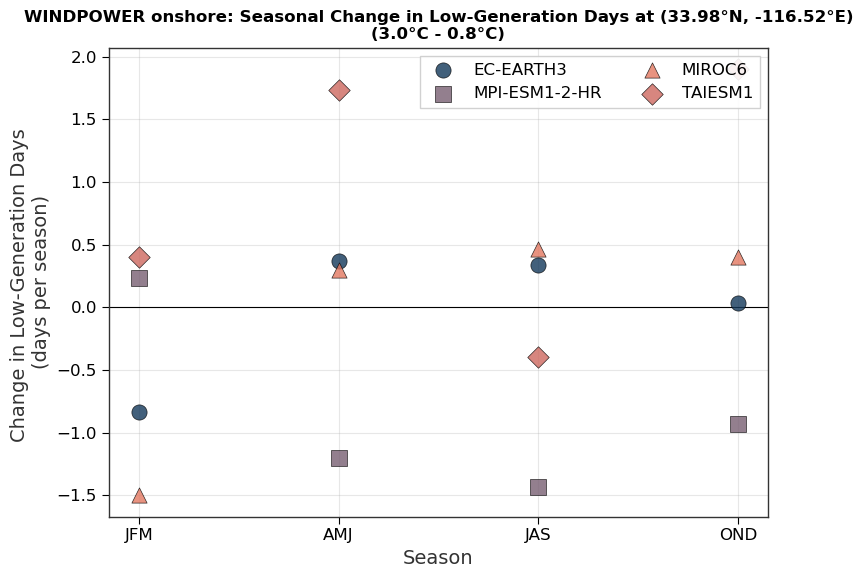

In [15]:
# Plot seasonal changes
fig, ax = plot_seasonal_changes(
    seasonal_changes,
    resource_name=f"{resource.upper()} {module}",
    location_data_dict=location_data_dict
)
plt.show()

### Optional: Print Detailed Statistics

In [16]:
# Calculate and display statistics across models
print("\\nMulti-Model Statistics:")
print("="*60)

for season in season_order:
    season_data = seasonal_changes[seasonal_changes['season'] == season]['change']
    mean_change = season_data.mean()
    std_change = season_data.std()
    
    print(f"{season}: {mean_change:+.1f} ± {std_change:.1f} days/season")

\nMulti-Model Statistics:
JFM: -0.4 ± 0.9 days/season
AMJ: +0.3 ± 1.2 days/season
JAS: -0.3 ± 0.9 days/season
OND: +0.4 ± 1.2 days/season


## Summary

This notebook provides a complete toolkit for analyzing location-specific changes in renewable generation:

1. **Annual profiles** show how the seasonal cycle of generation shifts under warming
2. **SEI heatmaps** reveal periods of persistently low or high generation and how they evolve
3. **Seasonal summaries** quantify changes in low-generation day frequency by season

### Key Patterns to Look For:

- **Increasing low-generation days** in certain seasons may indicate growing reliability challenges
- **SEI patterns** can reveal whether droughts are intensifying or if the timing shifts
- **Model agreement** (similar changes across models) suggests robust projections

### Next Steps:

- Try different locations to compare regional patterns
- Adjust the future GWL to explore sensitivity to warming levels
- Export results for further analysis or reporting

## Optional: Export Results

Uncomment and modify these cells to save your results.

In [17]:
# Save SEI data to NetCDF
for sim in simulations:
    output_path = f"../../data/location_analysis/sei_{resource}_{module}_{sim}_lat{target_lat}_lon{target_lon}.nc"
    sei_dict[sim].to_netcdf(output_path)
    print(f"Saved: {output_path}")


Saved: ../../data/location_analysis/sei_windpower_onshore_ec-earth3_lat33.9_lon-116.6.nc
Saved: ../../data/location_analysis/sei_windpower_onshore_mpi-esm1-2-hr_lat33.9_lon-116.6.nc
Saved: ../../data/location_analysis/sei_windpower_onshore_miroc6_lat33.9_lon-116.6.nc
Saved: ../../data/location_analysis/sei_windpower_onshore_taiesm1_lat33.9_lon-116.6.nc
